In [38]:
from dotenv import load_dotenv
import uuid
import os
from typing import Literal, TypedDict
from IPython.display import Image, display
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.types import Command, interrupt
from langgraph.graph import END, START, StateGraph
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

True

In [39]:
# Define the structural schemas for the email classification details
class EmailClassification(TypedDict):
    category: Literal["spam", "ham"]
    urgency: Literal["low", "medium", "high", "critical"]
    confidence: float
    summary: str


# Define the global Email Agent state schema
class EmailAgentState(TypedDict):
    email_content: str
    email_subject: str
    email_sender: str
    email_id: str

    classification: EmailClassification | None

    search_results: list[str] | None

    draft_response: str | None

In [40]:
llm = ChatOpenAI(
    model="gemini-2.5-flash-lite",
    base_url=os.getenv("OPENAI_API_BASE"),
    api_key=os.getenv("OPENAI_API_KEY")
)

In [41]:
# Node functions containing agent workflow logic

def read_email_content(state: EmailAgentState) -> str:
    """"Extracts the content of an email."""
    pass

def classify_email(state: EmailAgentState) -> EmailAgentState:
    """Classifies the email content into categories and urgency levels using ChatOpenAI structure mapping."""
    structured_llm = llm.with_structured_output(EmailClassification, method="json_mode")
    classification_prompt = f"""
You are an email classification agent. Your task is to classify the following email content into a category (spam or ham), 
determine its urgency level (low, medium, high, critical), and provide a confidence score (between 0 and 1). Additionally, 
identify the main topic of the email and provide a brief summary.

Email Content: {state['email_content']}
Email Subject: {state['email_subject']}
Email Sender: {state['email_sender']}
From: {state['email_sender']}

Please provide the output in the following JSON format:

{{
    "category": "spam or ham",
    "urgency": "low, medium, high, critical",
    "confidence": 0.0,
    "summary": "brief summary of the email"
}}
"""
    classification = structured_llm.invoke(classification_prompt)
    state["classification"] = classification
    return state

def search_documents(state: EmailAgentState) -> EmailAgentState:
    """Searches for relevant documents based on the email content (mocked document lookup)."""
    classification = state.get("classification", None)
    query = f"Search for documents related to the following email content: {state['email_content']}. Classification: {classification}"

    # Simulate a document search (replace with actual search logic)
    search_results = [f"Document {i+1} related to the email content" for i in range(3)]

    state["search_results"] = search_results
    return state

def write_draft_response(state: EmailAgentState) -> Command[Literal["review_draft", "send_reply"]]:
    """Generates a draft response to the email based on its classification and search results."""
    classification = state.get("classification", None) or {}
    search_results = state.get("search_results", [])
    
    draft_prompt = f"""
You are an email response agent. Based on the following email content, its classification, and the search results,
please draft a professional response to the email.

Email Content: {state['email_content']}
Classification: {classification.get('category', 'N/A')}
urgency: {classification.get('urgency', 'medium')}
Search Results: {search_results}

Please provide a concise and professional draft response. Do NOT include any "Subject:" line, headers, salutations to headers, or subject lines in your draft response. Just output the body of the email reply directly.
"""
    draft_response = llm.invoke(draft_prompt)

    # Route conditionally to Human-In-The-Loop review if urgency is high/critical or classified as spam
    needs_review = (
    classification.get('urgency') in ['high', 'critical'] or
    classification.get('category') == 'spam'
    )

    if needs_review:
        goto = "review_draft"
        print("Needs approval")
    else:
        goto = "send_reply"
    
    return Command(
        update = {"draft_response": draft_response.content},
        goto = goto
    )

def review_draft(state: EmailAgentState) -> Command[Literal["send_reply", END]]:
    """Pauses graph execution using interrupt to request reviewer validation and edits before dispatching."""
    classification = state.get('classification', None) or {}
    human_decision = interrupt({
        "email_sender" : state['email_sender'],
        "email_subject" : state['email_subject'],
        "email_content" : state['email_content'],
        "draft_response" : state['draft_response'],
        "category" : classification.get('category', 'N/A'),
        "urgency" : classification.get('urgency', 'medium'),
        "action" : "Please review the draft response and make any necessary edits before sending. You can also choose to send it as is or discard it."
    })

    if human_decision.get("approved"):
        return Command(
            update={"draft_response": human_decision.get("edited_response") or state['draft_response']},
            goto="send_reply"
        )
    else:
        return Command(update={}, goto=END)
    
def send_reply(state: EmailAgentState) -> EmailAgentState:
    """Mock final destination node representing dispatching the email response."""
    print(f"Sending email to {state['email_sender']} with subject '{state['email_subject']}' and content:\n{state['draft_response']}")
    return {}

In [42]:
builder = StateGraph(EmailAgentState)
builder.add_node("read_email", read_email_content)
builder.add_node("classify_email", classify_email)
builder.add_node("search_documents", search_documents)
builder.add_node("write_draft_response", write_draft_response)
builder.add_node("review_draft", review_draft)
builder.add_node("send_reply", send_reply)

builder.add_edge(START, "read_email")
builder.add_edge("read_email", "classify_email")
builder.add_edge("classify_email", "search_documents")
builder.add_edge("search_documents", "write_draft_response")
builder.add_edge("send_reply", END)

memory = InMemorySaver()
app = builder.compile(checkpointer = memory)

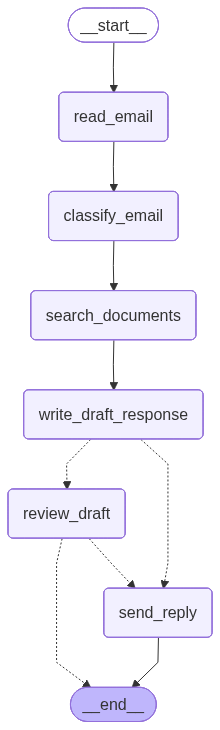

In [43]:
display(Image(app.get_graph().draw_mermaid_png()))

In [44]:
email_content = [
    "Hi how are you doing?",
    "Hello there! I was asking about the new product launch.",
    "Get a free gift card by clicking this link!",
    "Earn 100$  by clicking this link!"
]
needs_approval = []

for i, content in enumerate(email_content): 

    initial_state = {
        "email_content": content,
        "email_subject": f"Email Subject {i}",
        "email_sender": "mohamed@gmail.com",
        "email_id": f"email_{i}",
    }
    print(f"{initial_state['email_id']}: ", end="")

    thread_id = uuid.uuid4()
    config =  {"configurable": {"thread_id": thread_id}}
    result = app.invoke(initial_state, config)
    if "__interrupt__" in result.keys():
        result['thread_id'] = thread_id
        needs_approval.append(result)

email_0: Sending email to mohamed@gmail.com with subject 'Email Subject 0' and content:
I am doing well, thank you for asking. How can I assist you today?
email_1: Sending email to mohamed@gmail.com with subject 'Email Subject 1' and content:
Thank you for your interest in our upcoming product launch. We are excited to share that all relevant details regarding the release, including specifications and timelines, are outlined in the documentation attached for your review.

Please let us know if you have any further questions after looking through these materials. We look forward to sharing more with you soon.
email_2: Needs approval
email_3: Needs approval
